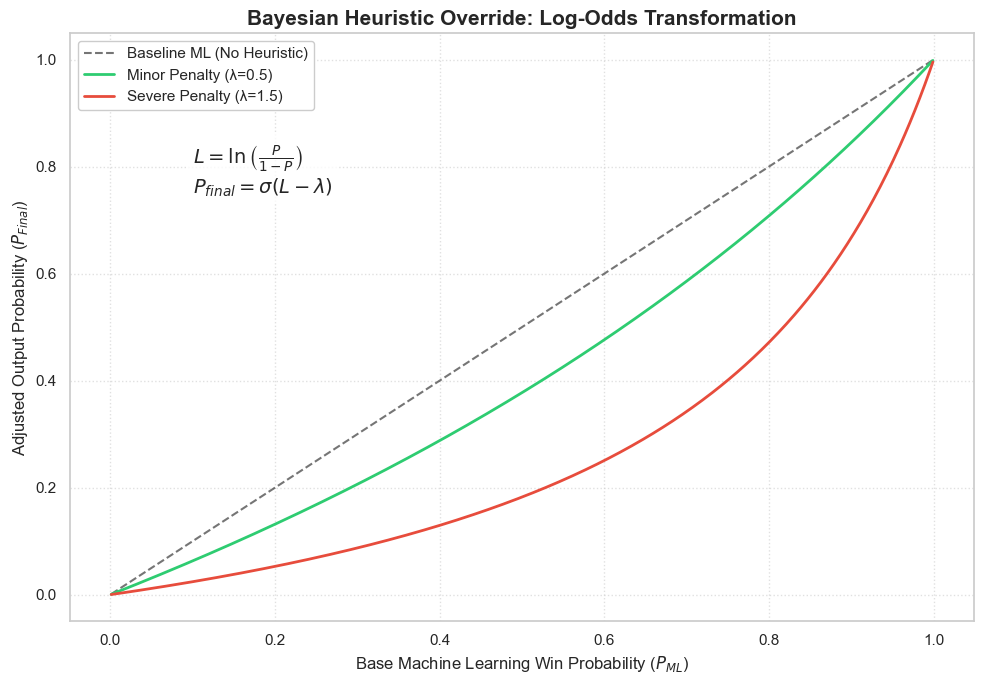

📝 RESEARCH NOTE: This curve demonstrates the Sigmoid Squeeze.
Unlike linear subtraction, Log-Odds penalties become more conservative
as they approach 0, preventing mathematically impossible negative probabilities.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set professional thesis theme
sns.set_theme(style="whitegrid", context="notebook")

def apply_heuristic_penalty(base_probability, penalty_value):
    """
    Applies a Bayesian update to a probability using the Log-Odds (Logit) transform.
    This ensures the final probability remains bounded between (0, 1).
    """
    # Step 1: Convert probability to Log-Odds (Logit)
    # Equation: L = ln(P / (1 - P))
    # Clip probabilities to avoid division by zero or log(0)
    p = np.clip(base_probability, 1e-7, 1 - 1e-7)
    logit = np.log(p / (1 - p))
    
    # Step 2: Apply the expert penalty (Subtracted from the log-odds)
    new_logit = logit - penalty_value
    
    # Step 3: Convert back to probability via Sigmoid function
    # Equation: P_final = 1 / (1 + e^-L_new)
    final_prob = 1 / (1 + np.exp(-new_logit))
    return final_prob

# ==========================================
# 1. SIMULATION SETUP
# ==========================================
# Generate a range of base ML probabilities from 0.1% to 99.9%
base_probs = np.linspace(0.001, 0.999, 500)

# Simulate different "Expert Levels" of penalties
# Penalty 1.5 is a severe Bayesian update (e.g., Missing Smite)
# Penalty 0.5 is a minor update (e.g., Off-meta pick)
severe_penalty = 1.5
minor_penalty = 0.5

# Calculate adjusted probabilities
penalized_severe = [apply_heuristic_penalty(p, severe_penalty) for p in base_probs]
penalized_minor = [apply_heuristic_penalty(p, minor_penalty) for p in base_probs]

# ==========================================
# 2. VISUALIZATION OF MATHEMATICAL PROOF
# ==========================================


plt.figure(figsize=(10, 7))

# Plot the 1:1 Identity Line (No Penalty)
plt.plot(base_probs, base_probs, 'k--', alpha=0.6, label='Baseline ML (No Heuristic)')

# Plot Adjusted Curves
plt.plot(base_probs, penalized_minor, color='#2ecc71', linewidth=2, label=f'Minor Penalty (λ={minor_penalty})')
plt.plot(base_probs, penalized_severe, color='#e74c3c', linewidth=2, label=f'Severe Penalty (λ={severe_penalty})')

# Academic Formatting
plt.title('Bayesian Heuristic Override: Log-Odds Transformation', fontsize=15, fontweight='bold')
plt.xlabel('Base Machine Learning Win Probability ($P_{ML}$)', fontsize=12)
plt.ylabel('Adjusted Output Probability ($P_{Final}$)', fontsize=12)
plt.legend(frameon=True, facecolor='white', framealpha=1)
plt.grid(True, linestyle=':', alpha=0.6)

# Highlight the "Sigmoid Squeeze"
plt.text(0.1, 0.75, r"$L = \ln\left(\frac{P}{1-P}\right)$" + "\n" + r"$P_{final} = \sigma(L - \lambda)$", 
         fontsize=14, bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

plt.tight_layout()
plt.show()

print("📝 RESEARCH NOTE: This curve demonstrates the Sigmoid Squeeze.")
print("Unlike linear subtraction, Log-Odds penalties become more conservative")
print("as they approach 0, preventing mathematically impossible negative probabilities.")